# Zero-Preserving Split Normalization (Z-Split)

**Author:** Abdulrhman Almoadi  
**Affiliation:** King Abdulaziz City for Science and Technology (KACST)

## Citation
If you use this code, please cite:
> Almoadi, A.: Reducing False Alarms in Urban Flood Detection: An Enhanced NDWI (ENDWI) with Hybrid Max Fusion on Sentinel-2 Data, EGUsphere [preprint], https://doi.org/10.5194/egusphere-2026-672, 2026.

## Description
Z-Split is a normalization technique designed for **bipolar spectral indices** — indices containing both positive and negative values — where conventional normalization displaces the natural zero boundary.

### Key Properties:
- Positive values → normalized to **[0, 1]**
- Negative values → normalized to **[-1, 0]**
- Zero → **strictly preserved** as the natural boundary between classes

## Mathematical Formulation

$$
ENDWI_{zsplit}(x) = 
\begin{cases}
\dfrac{x - \min(X^+)}{\max(X^+) - \min(X^+)} & \text{if } x > 0 \\[10pt]
0 & \text{if } x = 0 \\[10pt]
\dfrac{x - \min(X^-)}{\max(X^-) - \min(X^-)} - 1 & \text{if } x < 0
\end{cases}
$$

Where:
- $X^+ = \{x \in X : x > 0\}$ — set of positive values
- $X^- = \{x \in X : x < 0\}$ — set of negative values

In [2]:
import numpy as np
import rasterio
import matplotlib.pyplot as plt

In [3]:
def zsplit_normalization(input_path, output_path=None):
    """
    Zero-Preserving Split Normalization (Z-Split)
    
    Applicable to any bipolar spectral index.
    
    Parameters:
    -----------
    input_path  : str — path to input raster
    output_path : str — path to save output (optional)
    
    Returns:
    --------
    result : numpy array — normalized values in [-1, +1]
    """
    
    with rasterio.open(input_path) as src:
        arr = src.read(1).astype(float)
        profile = src.profile
        nodata = src.nodata
    
    # Mask nodata
    if nodata is not None:
        arr[arr == nodata] = np.nan
    
    result = np.zeros_like(arr, dtype=float)
    
    pos_mask = arr > 0
    neg_mask = arr < 0
    
    # Normalize positive to [0, 1]
    if pos_mask.any():
        pos_max = np.nanmax(arr[pos_mask])
        pos_min = np.nanmin(arr[pos_mask])
        if pos_max != pos_min:
            result[pos_mask] = (arr[pos_mask] - pos_min) / (pos_max - pos_min)
        else:
            result[pos_mask] = 1.0
    
    # Normalize negative to [-1, 0]
    if neg_mask.any():
        neg_max = np.nanmax(arr[neg_mask])
        neg_min = np.nanmin(arr[neg_mask])
        if neg_max != neg_min:
            result[neg_mask] = (arr[neg_mask] - neg_min) / (neg_max - neg_min) - 1
        else:
            result[neg_mask] = -1.0
    
    # Preserve NaN
    result[np.isnan(arr)] = np.nan
    
    # Save if path provided
    if output_path:
        profile.update(dtype=rasterio.float32, count=1, nodata=np.nan)
        with rasterio.open(output_path, 'w', **profile) as dst:
            dst.write(result.astype(rasterio.float32), 1)
        print(f"Saved: {output_path}")
    
    return result, arr

Saved: F:\KSU_LEVEL_3\Dr_AlTwajeri_Included_ENDWI\Analysis_Part4\ENDWI_zsplit_test.tif


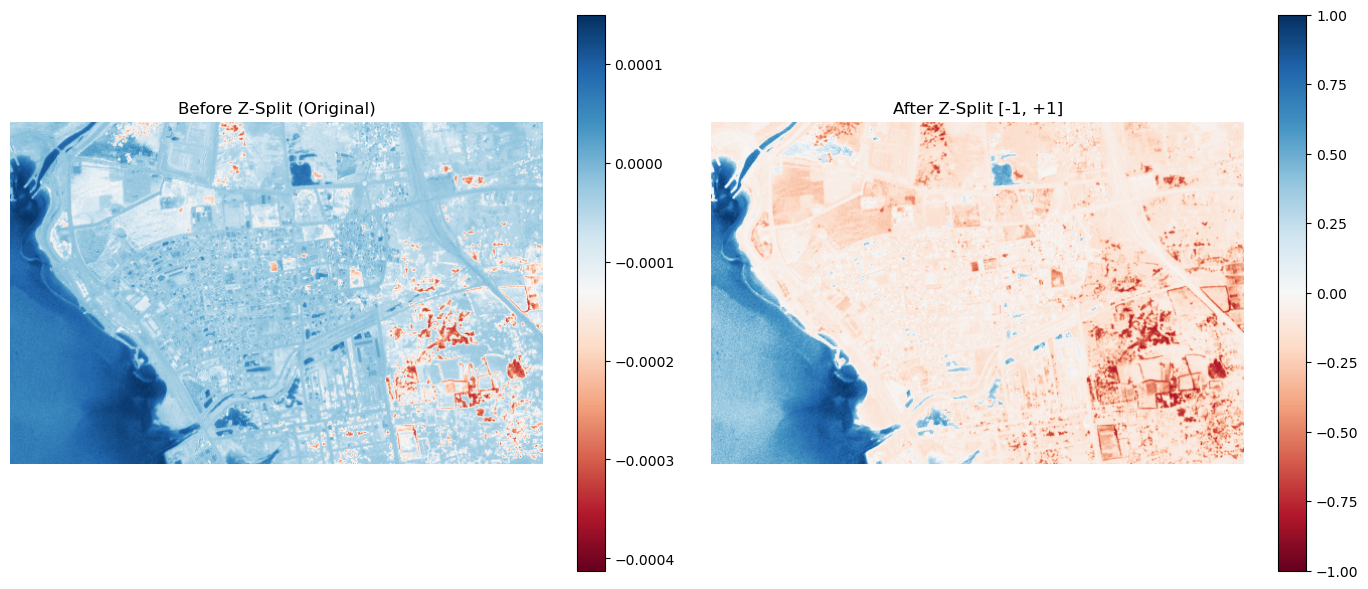

Original range: -0.000412 to 0.000150
Z-Split range:  -1.000000 to 1.000000


In [6]:
# ─────────────────────────────────
# Modify paths according to your data
# ─────────────────────────────────
input_path  = r"F:\KSU_LEVEL_3\Dr_AlTwajeri_Included_ENDWI\Analysis_Part4\1_Raw_Indices\ENDWI_raw.tif"
output_path = r"F:\KSU_LEVEL_3\Dr_AlTwajeri_Included_ENDWI\Analysis_Part4\ENDWI_zsplit_test.tif"

# Run Z-Split
result, original = zsplit_normalization(input_path, output_path)

# Plot
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

axes[0].imshow(original, cmap='RdBu', 
               vmin=np.nanmin(original), 
               vmax=np.nanmax(original))
axes[0].set_title('Before Z-Split (Original)')
axes[0].axis('off')
plt.colorbar(axes[0].images[0], ax=axes[0])

axes[1].imshow(result, cmap='RdBu', vmin=-1, vmax=1)
axes[1].set_title('After Z-Split [-1, +1]')
axes[1].axis('off')
plt.colorbar(axes[1].images[0], ax=axes[1])

plt.tight_layout()
plt.show()

print(f"Original range: {np.nanmin(original):.6f} to {np.nanmax(original):.6f}")
print(f"Z-Split range:  {np.nanmin(result):.6f} to {np.nanmax(result):.6f}")

## Visual Comparison

The left image shows the original ENDWI values — visual discrimination 
between water (blue) and urban surfaces (red) is preserved, but the 
extremely narrow range (-0.000412 to +0.000150) renders automatic 
thresholding unreliable.

After Z-Split (right), the same spectral information is retained but 
expanded to [-1, +1], enabling Otsu's method to identify a stable 
threshold between flooded and non-flooded pixels.

**Key insight:** Z-Split does not alter spectral information — 
it only rescales the distribution to make automatic thresholding feasible.